<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter4/4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 확률적 경사 하강법

점진적 학습 또는 온라인 학습의 대표적인 알고리즘이다.

전체 데이터를 한꺼번에 사용하는 것이 아니라, 데이터를 하나씩(또는 소량으로) 꺼내어 모델의 가중치를 업데이트하는 최적화 알고리즘.

기존에 학습된 가중치를 유지한 채 새로운 데이터의 기울기만 반영하여 미세 조정하기 때문.

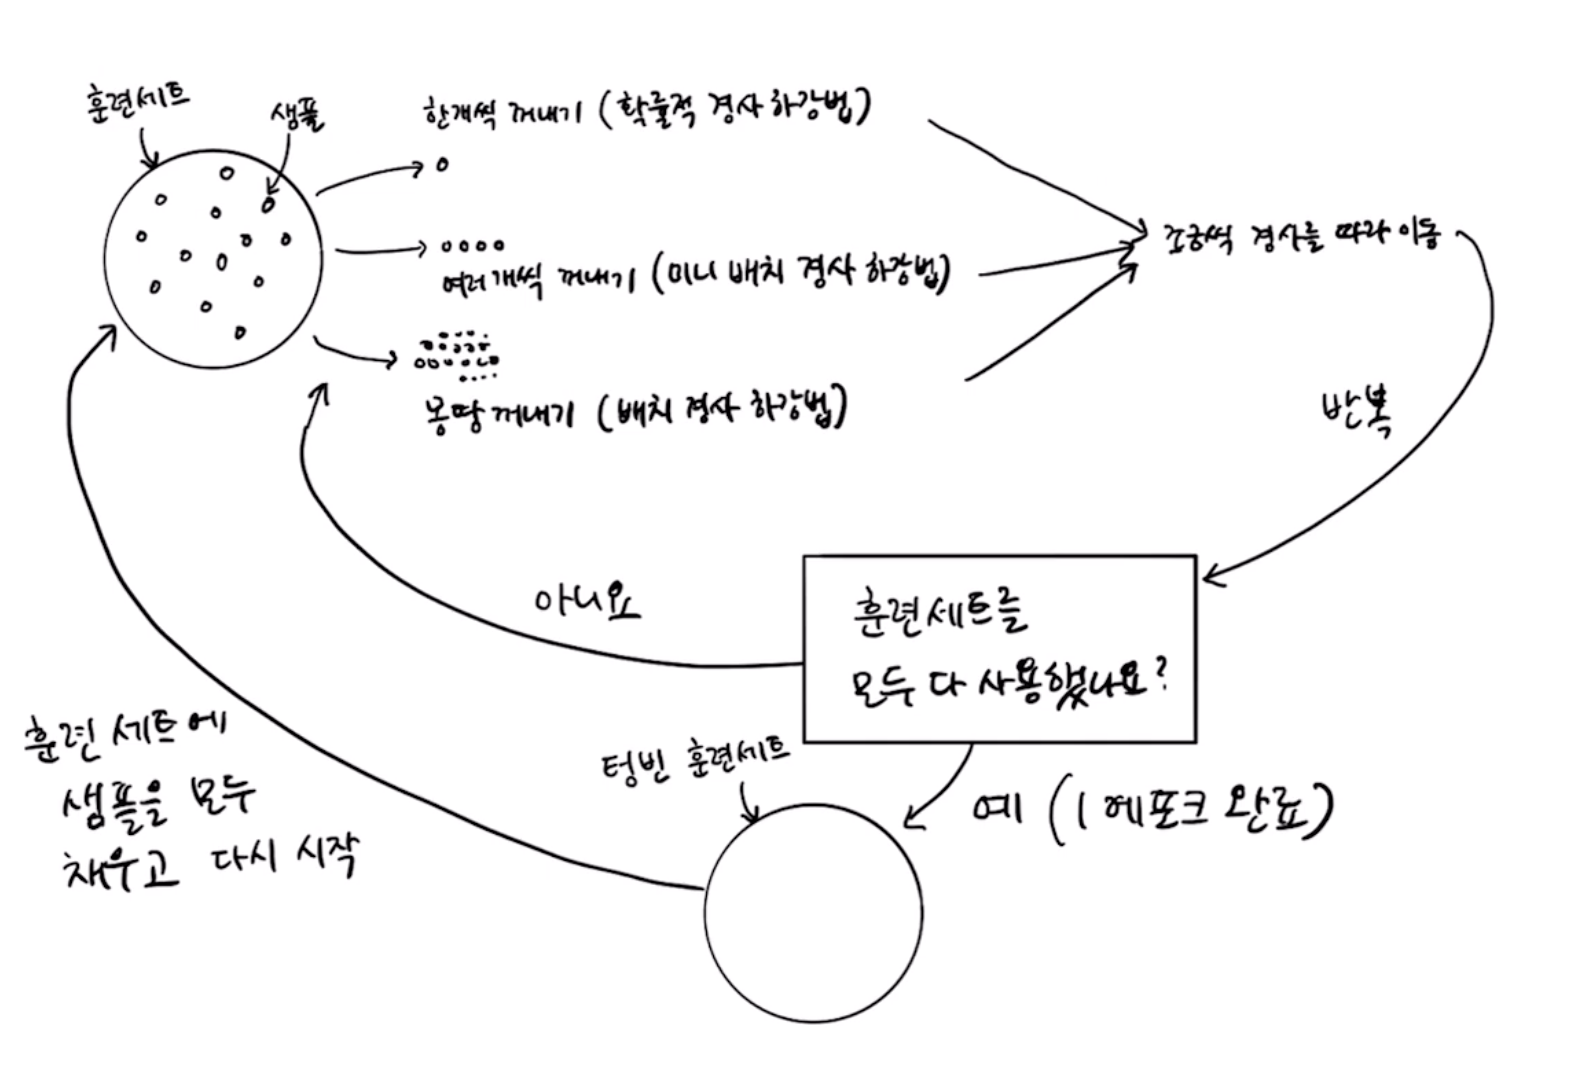

## 확률적 경사 하강법(SGD)

## 로지스틱 손실 함수
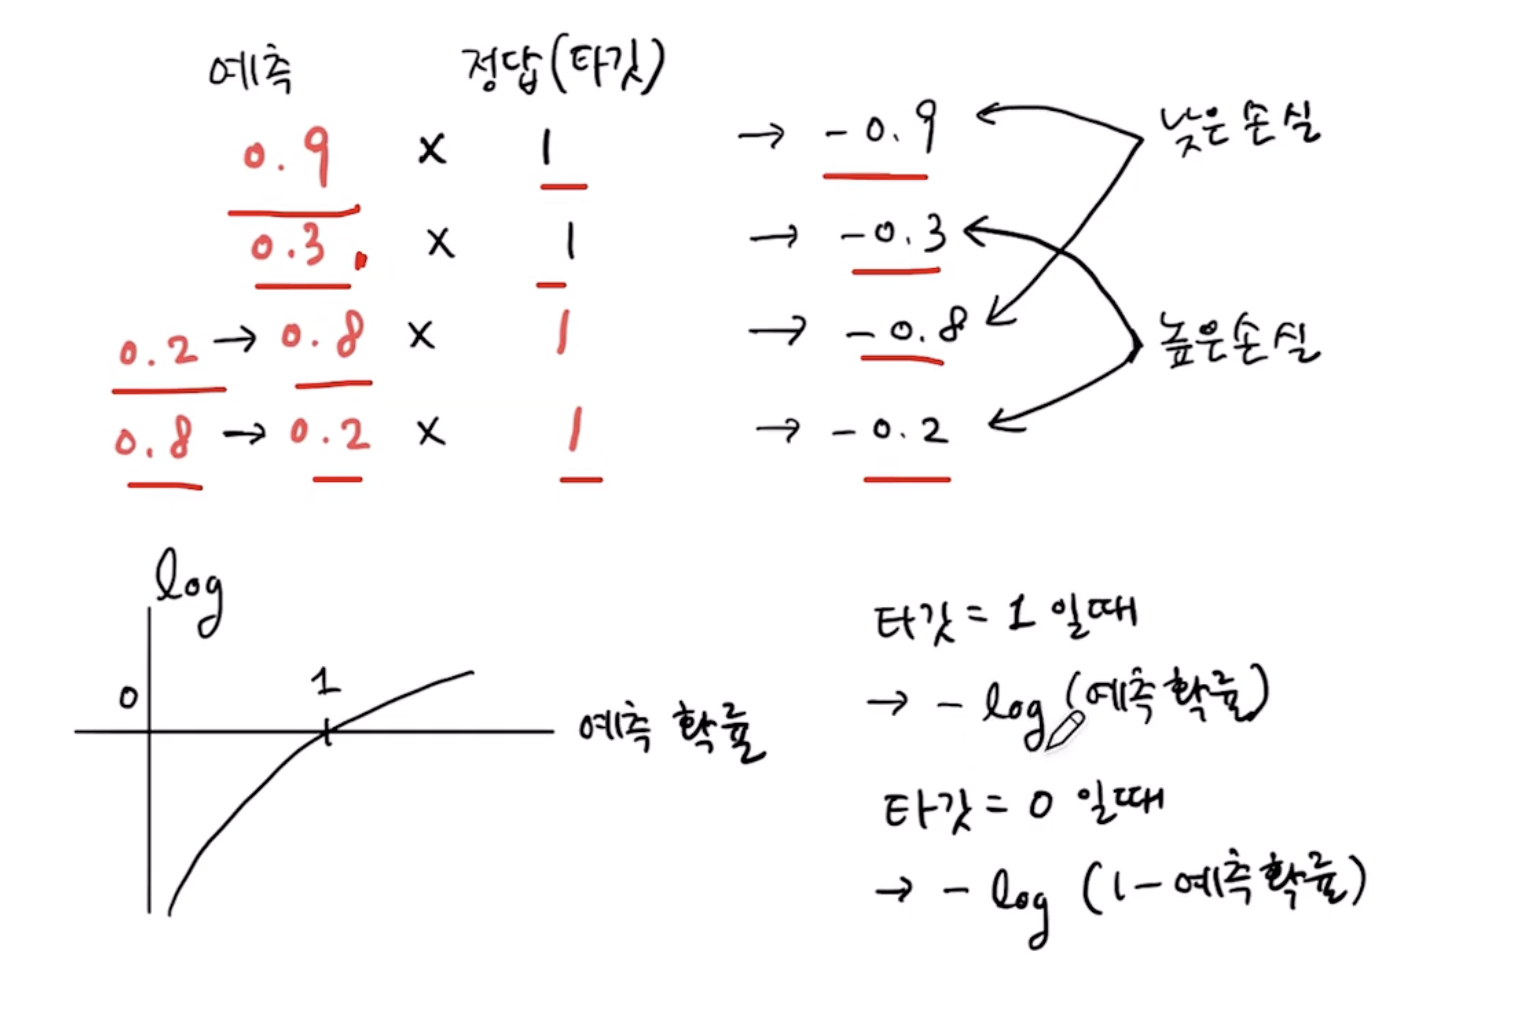

## 확률적 경사 하강법을 사용한 분류 모델을 만들어 보기

In [4]:
#데이터 가져오기
import pandas as pd

fish = pd.read_csv('https://bit.ly/fish_csv_data')

fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
fish_target = fish['Species']

In [5]:
#훈련세트와 타깃세트로 분류하기
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state = 42)

#표준화 전처리
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [6]:
#SGDClassifier
from sklearn.linear_model import SGDClassifier

#로지스틱 손실 함수 지정해서 훈련
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)

#스코어 확인
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


스코어가 낮고 반복 횟수가 부족하다는 경고를 보냄.

확률적 경사 하강법은 점진적 학습이 가능하다. SGDClassifier 객체를 새로 만들지 않고 훈련한 모델 sc를 추가로 더 훈련해 볼수 있다.

그 방법이 partial_fit() 메서드. 호출할때 마다 1에포크씩 이어서 훈련할 수 있다.

In [7]:
#추가로 훈련하기
sc.partial_fit(train_scaled, train_target)

#스코어 확인
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.7983193277310925
0.775


## 에포크와 과대/과소적합
무작정 많이 반복할 수는 없고 기준이 필요하다.

에포크와 과대/과소적합을 보면 밑 그림은 에포크가 진행됨에 따라 모델의 정확도를 나타낸것이다.
훈련세트 점수는 에포크가 진행될수록 꾸준히 증가하지만 테스트 세트 점수는 어느 순간 감소되어 과대적합이 시작된다.

과대적합이 시작되기전 훈련을 멈추는 것을 조기종료라 부른다.
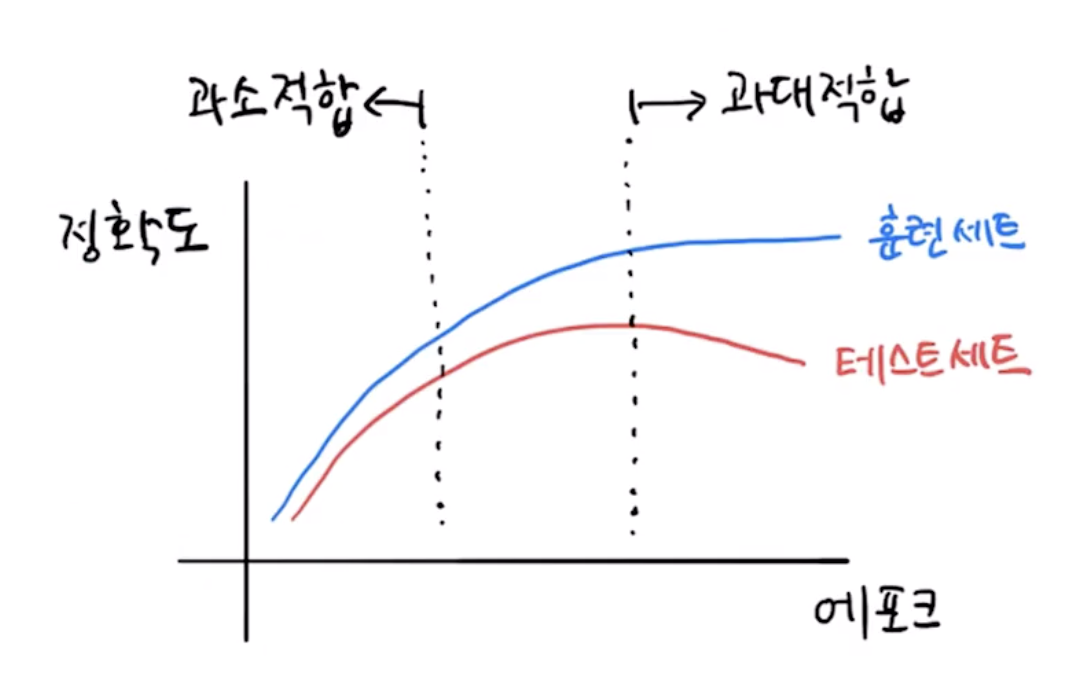

In [8]:
#위와같은 그래프 만들어보기
import numpy as np

sc = SGDClassifier(loss='log_loss', random_state=42)

#점수 리스트
train_score = []
test_score = []

#생선목록
classes = np.unique(train_target)

In [9]:
#300번 에포크 동안 훈련 반복
for _ in range(0, 300):
  sc.partial_fit(train_scaled, train_target, classes=classes)
  train_score.append(sc.score(train_scaled, train_target))
  test_score.append(sc.score(test_scaled, test_target))

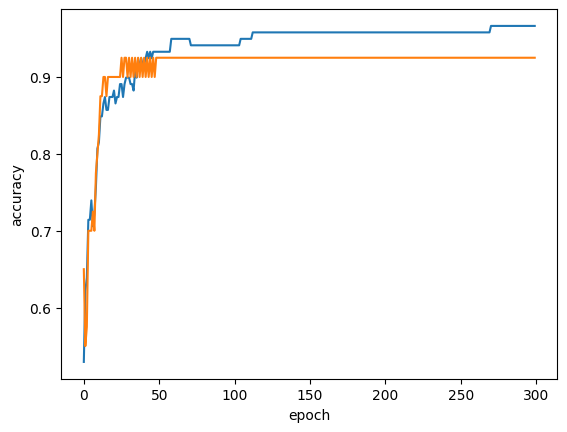

In [11]:
#그래프 그리기
import matplotlib.pyplot as plt

plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [12]:
#100번 이후로 점수가 조금씩 벌어진다고 볼수 있음.
#에포크 초기에는 과소적합되어 점수가 낮다.
#반복 횟수는 100번이 적절하다고 볼수 있다.
#반복 횟수를 100으로 지정하고 다시 훈련
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)

#스코어 확인
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925
